In [1]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_threefry_partitionable", True)

In [2]:
def plot_gvcorr(gc, color='blue', log_scale=False, offset=0.0, x=None, xr_offset=True, 
    label=None, marker='o', markersize=8, capthick=0, open_symbol=False, fill=False, linestyle=' ', eb_linestyle=' '):
    if x is None:
        x = np.arange(0,len(gc))

    if fill:
        y = np.asarray([gv.mean(g) for g in gc])
        yerr = np.asarray([gv.sdev(g) for g in gc])
        eplot = plt.plot(x=x+offset, y=y, color=color, label=label)
        eplot = plt.fill_between(x+offset, y-yerr, y+yerr, alpha=0.5, edgecolor='k', facecolor=color)
    else:
        if open_symbol:
            eplot = plt.errorbar(x=x + offset, y=[ gv.mean(g) for g in gc], yerr= [gv.sdev(g) for g in gc], 
                marker=marker, markersize=markersize, capthick=capthick, 
                linestyle=linestyle, color=color, label=label, mfc='None', mec=color, mew=1)
        else:
            eplot = plt.errorbar(x=x + offset, y=[ gv.mean(g) for g in gc], yerr= [gv.sdev(g) for g in gc], 
                marker=marker, markersize=markersize, capthick=capthick, 
                linestyle=linestyle, color=color, label=label)
						 
        if eb_linestyle != ' ':
            eplot[-1][0].set_linestyle(eb_linestyle)

    if (log_scale):
        plt.yscale('symlog')
    
    if (xr_offset):
        plt.xlim(x[0]-0.2, x[-1]+0.2)

    return eplot

In [3]:
d=2

class ACAction(lhmc.Action):
    @staticmethod
    @jax.jit
    def _Sjax(phi, beta, lamb):
        Stot = phi**2
        for mu in range(d):
            Stot -= beta * phi * phi.nn_field(mu)

        Stot += lamb * (phi**2 - 1)**2

        return Stot

    def _compute_forces(self):
        self.grads = {
            'phi': jax.jit(jax.grad(lambda phi, beta, lamb: jnp.sum(self._Sjax(phi, beta, lamb).F))),
        }

        def force_func(fields):
            return {'phi': self.grads['phi'](fields['phi'], self.params['beta'], self.params['lamb']) }

        self.forces = force_func


In [14]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.F)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

def S(phi, beta, lamb):
    Stot = phi**2
    for mu in range(d):
        Stot -= beta * phi * phi.nn_field(mu)

    Stot += lamb * (phi**2 - 1)**2

    return Stot

In [20]:
betas = np.linspace(0.675,0.685,5)
vols = np.array([16, 24, 32])
mags = {}

for L in vols:
    mags[L] = {}
    Lat_scan = lat.SquareLattice(dims=(L,L))
    phi_scan = lat.LatticeField(Lat_scan)
    phi_scan.field = np.ones_like(phi_scan.F)
    
    for b in betas:
        S_scan = ACAction({'phi': phi_scan}, params={'beta': b, 'lamb': 1.0})
    
        HMC = lhmc.HMCEvolver(
            action=S_scan,
            seed=int(68015+b*138+L*59),
            integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
            observables={'mag': (mag_obs, 500)},
        )
    
        HMC.evolve(ntraj=500, warmup=True)
    
        for _ in range(500):
            HMC.evolve(ntraj=1000)
    
        print(f"L = {L}, beta = {b}: avg. accept prob = ", np.mean(HMC.monitor['P_acc']))
    
        mags[L][b] = np.array(HMC.obs_chain['mag'])


L = 16, beta = 0.675: avg. accept prob =  0.9998784074835295
L = 16, beta = 0.6775: avg. accept prob =  0.9999075534887296
L = 16, beta = 0.68: avg. accept prob =  0.9999369445191869
L = 16, beta = 0.6825000000000001: avg. accept prob =  0.9998905811586538
L = 16, beta = 0.685: avg. accept prob =  0.9996742410024888
L = 24, beta = 0.675: avg. accept prob =  1.000084455278958
L = 24, beta = 0.6775: avg. accept prob =  1.0004002710705733
L = 24, beta = 0.68: avg. accept prob =  0.9999160703438112
L = 24, beta = 0.6825000000000001: avg. accept prob =  0.9997990004062474
L = 24, beta = 0.685: avg. accept prob =  1.0001015743092865
L = 32, beta = 0.675: avg. accept prob =  1.0009169722856608
L = 32, beta = 0.6775: avg. accept prob =  1.0010981695038754
L = 32, beta = 0.68: avg. accept prob =  1.000121221176087
L = 32, beta = 0.6825000000000001: avg. accept prob =  0.9997941601484284
L = 32, beta = 0.685: avg. accept prob =  1.000201766481725


In [21]:
np.mean(HMC.monitor['P_acc'])

1.000201766481725

In [22]:
def binder(mag_array, tc=0):
    m2_ave = np.mean(mag_array[tc:,1])
    m4_ave = np.mean(mag_array[tc:,2])

    return 1.5 - m4_ave / (2 * m2_ave**2)

def binder_jk(mag_array, tc=0):
    BC_jack = []
    Nsamp = mag_array.shape[0]
    mu_BC = binder(mag_array, tc=tc)

    for i in range(Nsamp):
        mag_i = np.delete(mag_array, i, axis=0)
        BC_i = binder(mag_i, tc=tc)
        BC_jack.append(Nsamp*mu_BC - (Nsamp-1)*BC_i)

    mu_J = np.mean(BC_jack)
    sdev_J = np.std(BC_jack) / np.sqrt(Nsamp-1)
    return gv.gvar(mu_J, sdev_J)

{16: [0.8837(63), 0.8867(62), 0.8990(56), 0.9152(49), 0.9183(49)], 24: [0.8554(78), 0.8912(60), 0.9178(48), 0.9267(45), 0.9442(36)], 32: [0.8463(80), 0.8784(66), 0.9094(54), 0.9385(38), 0.9417(39)]}


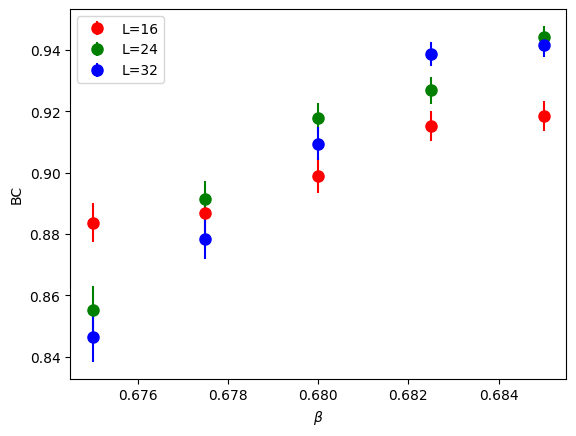

In [26]:
BC = {}
colors=['r','g','b']
for L in vols:
    BC[L] = []
    for b in betas:
        BC[L].append(binder_jk(mags[L][b][::1,:], tc=0))
print(BC)
for i in range(3):
    plot_gvcorr(BC[vols[i]], x=betas, xr_offset=False, color=colors[i],  label=f'L={vols[i]}')
plt.xlabel('$\\beta$')
plt.ylabel('BC')
plt.legend()

In [8]:
# Try to run at critical point
S8 = ACAction({'phi': phi8}, params={'beta': 0.6, 'lamb': 1})

HMC = lhmc.HMCEvolver(
    action=S8,
    seed=int(68015+b*138),
    integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
    observables={'mag': (mag_obs, 500)},
)

HMC.evolve(ntraj=500, warmup=True)

for _ in range(200):
    HMC.evolve(ntraj=1000)

NameError: name 'phi8' is not defined

In [84]:
binder_jk(np.array(HMC.obs_chain['mag']), tc=0)

0.562(31)

In [5]:
# Try to run at critical point
Lat16 = lat.SquareLattice(dims=(16,16))
phi16 = lat.LatticeField(Lat16)
phi16.field = np.ones_like(phi16.F)

S16 = ACAction({'phi': phi16}, params={'beta': 0.5985, 'lamb': 0.06268})

HMC = lhmc.HMCEvolver(
    action=S16,
    seed=int(68015+b*138),
    integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
    observables={'mag': (mag_obs, 5000)},
)

HMC.evolve(ntraj=500, warmup=True)

for _ in range(200):
    HMC.evolve(ntraj=1000)

I0000 00:00:1701970173.262270       1 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


NameError: name 'b' is not defined

In [69]:
np.mean(HMC.monitor['P_acc'])
binder_jk(np.array(HMC.obs_chain['mag'])[::1,:], tc=0)

0.9863(38)

In [70]:
# Volume scaling?
mags_V = {}

for L in [8, 12, 16, 24, 32]:
    LatV = lat.SquareLattice(dims=(L,L))
    phiV = lat.LatticeField(LatV)
    phiV.field = np.ones_like(phiV.F)

    SV = ACAction({'phi': phiV}, params={'beta': 0.5985, 'lamb': 0.06268})
    
    HMC = lhmc.HMCEvolver(
        action=SV,
        seed=int(81033+b*7311),
        integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
        observables={'mag': (mag_obs, 5000)},
    )

    HMC.evolve(ntraj=500, warmup=True)

    for _ in range(200):
        HMC.evolve(ntraj=1000)

    print(f"L = {L}: avg. accept prob = ", np.mean(HMC.monitor['P_acc']))

    mags_V[L] = np.array(HMC.obs_chain['mag'])


L = 8: avg. accept prob =  0.999997067634594
L = 12: avg. accept prob =  1.000000167326614
L = 16: avg. accept prob =  0.9999911313893742
L = 24: avg. accept prob =  0.9999972595654
L = 32: avg. accept prob =  0.9999882855577589


[0.940(18), 0.962(10), 0.9831(40), 0.9905(23), 0.9939(11)]
[ 8 12 16 24 32]


<ErrorbarContainer object of 3 artists>

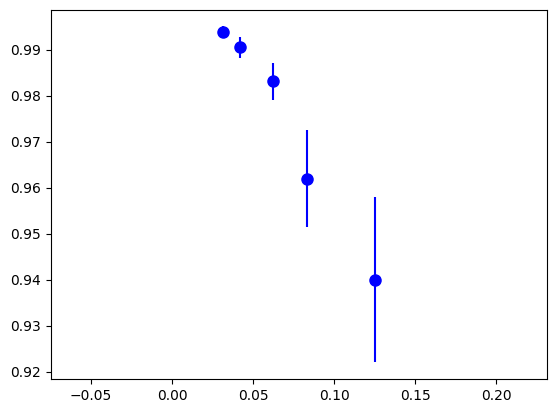

In [76]:
BC_V = []
for L in mags_V.keys():
    BC_V.append(binder_jk(mags_V[L], tc=0))
print(BC_V)
Ls = np.array(list(mags_V.keys()))
print(Ls)
plot_gvcorr(BC_V, x=1/Ls)

In [26]:
# Reproduce Anna on L=16
Lat16 = lat.SquareLattice(dims=(16,16))
phi16 = lat.LatticeField(Lat16)
phi16.field = np.ones_like(phi16.F)

S16 = ACAction({'phi': phi16}, params={'beta': 0.68000, 'lamb': 1.0000})

def S_obs(fields, params):
    return jnp.sum(S(fields['phi'], 0.680, 1.000).F)

HMC = lhmc.HMCEvolver(
    action=S16,
    seed=int(583859),
    integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
    observables={'mag': (mag_obs, 500), 'S': (S_obs, 500)},
)

HMC.evolve(ntraj=500, warmup=True)

for _ in range(200):
    HMC.evolve(ntraj=1000)

In [41]:
fields = np.array([ field.F for field in HMC.field_chain['phi'] ])
fields = fields[500::1,:,:]
fields.shape

(200001, 16, 16)

In [50]:
def mag_ens(phi):
    return np.sum(phi, axis=(1,2))

def AC_Gamma(phi, t):
    M = mag_ens(phi)
    N = len(M)
    
    mu = np.mean(M)
    
    return N/(N-1) * ( np.mean(M * np.roll(M,t)) - mu**2)

def tau_int(phi, W):
    tau = 0.0
    for t in range(1,W):
        tau += AC_Gamma(phi, t)
        
    return 0.5 + tau / AC_Gamma(phi, 0)

In [56]:
tau_int(fields, 2000)

1207.3803986596079

112.90567779125777

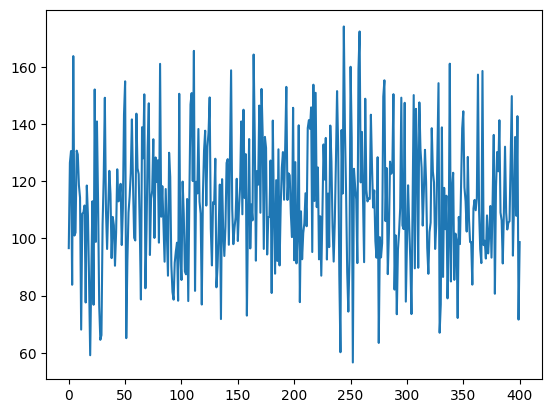

In [27]:
plt.plot(HMC.obs_chain['S'])
np.mean(HMC.obs_chain['S'])

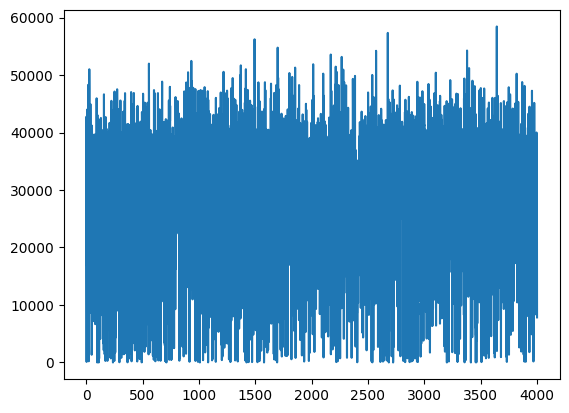

In [20]:
mags = np.array(HMC.obs_chain['mag'])
plt.plot(mags[:,1])

In [23]:
np.mean(HMC.monitor['P_acc'])
binder_jk(np.array(HMC.obs_chain['mag'])[::20,:], tc=0)

0.917(11)

In [24]:
len(np.array(HMC.obs_chain['mag'])[::20,:])

201